# Rethinking Symbolic Regression Datasets and Benchmarks for Scientific Discovery (SRSD)

**Paper:** Matsubara, Y., Chiba, N., Igarashi, R., & Ushiku, Y. (2024). *Rethinking Symbolic Regression Datasets and Benchmarks for Scientific Discovery.* Journal of Data-centric Machine Learning Research.

**Carpeta origen:** `Papers/05_Benchmarks_y_Datasets/Matsubara_etal_2022_SRSD.pdf`

## Que se reproduce en este cuaderno

El banco de datos Feynman original (usado en los cuadernos de AI Feynman de esta coleccion) muestrea las variables de entrada en rangos **arbitrarios**, no necesariamente representativos de los valores fisicamente plausibles de cada ecuacion. El paper argumenta que esto es un problema serio: un rango de muestreo poco representativo puede hacer que una formula **estructuralmente incorrecta** parezca numericamente excelente, simplemente porque el rango elegido no expone donde falla.

Reproducimos este fenomeno de forma directa: buscamos la ley $f(x)=\sin(x)$ bajo dos rangos de muestreo distintos, y comparamos una hipotesis correcta ($\sin(x)$) contra una incorrecta pero **localmente parecida** ($x$, la aproximacion de angulo pequeno $\sin(x)\approx x$):

1. Bajo un rango **arbitrario y estrecho** ($x\in[-0.3,0.3]$): la aproximacion $x$ parece casi perfecta.
2. Bajo un rango **fisicamente representativo** ($x\in[-2\pi,2\pi]$, que cubre al menos un periodo completo): $x$ falla estrepitosamente.

Ademas, implementamos una version simplificada de la metrica que propone el paper -- la **Distancia de Edicion Normalizada (NED)** entre el arbol de expresion descubierto y el arbol de la formula real -- y mostramos que **delata la diferencia estructural entre $\sin(x)$ y $x$ inmediatamente**, sin depender en absoluto de que rango de muestreo se haya elegido.

## Repositorio publico

El paper publica su codigo y los 240 datasets SRSD bajo `omron-sinicx/srsd-benchmark` (GitHub) -- no esta clonado localmente en este proyecto. Reimplementamos aqui, de forma simplificada, el principio de comparar rangos de muestreo y una version basica de la metrica NED que introduce el paper.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. La metrica NED: distancia de edicion de arboles normalizada

Representamos cada expresion como un arbol simple, y calculamos una distancia de edicion (version simplificada, posicional, del mismo principio que usa el paper) entre dos arboles: cuenta cuantas sustituciones/inserciones/eliminaciones de nodos hacen falta para transformar un arbol en el otro, normalizada por el tamano del arbol mas grande.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def size(node):
    if node[0] in ('var', 'const'): return 1
    if node[0] == 'op1': return 1 + size(node[2][0])
    return 1 + size(node[2][0]) + size(node[2][1])

def label(node):
    return (node[0], node[1] if node[0] != 'var' else 'x')

def children(node):
    return [] if node[0] in ('var', 'const') else node[2]

def ted(a, b):
    # Distancia de edicion de arboles simplificada (posicional): penaliza diferencias de
    # etiqueta nodo a nodo y el tamano de las subramas que sobran o faltan.
    if a is None and b is None: return 0
    if a is None: return size(b)
    if b is None: return size(a)
    cost_sub = 0 if label(a) == label(b) else 1
    ca, cb = children(a), children(b)
    total = cost_sub
    for i in range(max(len(ca), len(cb))):
        x = ca[i] if i < len(ca) else None
        y = cb[i] if i < len(cb) else None
        total += ted(x, y)
    return total

def ned(a, b):
    return ted(a, b) / max(size(a), size(b))

sin_expr = ('op1', 'sin', [('var', 0)])
identity_expr = ('var', 0)

d_ned = ned(sin_expr, identity_expr)
print(f'NED entre "sin(x)" y "x": {d_ned:.3f}   (0 = identicas, 1 = completamente distintas)')

NED entre "sin(x)" y "x": 1.000   (0 = identicas, 1 = completamente distintas)


## 2. El mismo par de hipotesis, bajo dos rangos de muestreo

rango de muestreo              MSE de x (incorrecta)  MSE de sin(x) (correcta)
arbitrario [-0.3, 0.3]                      0.000003                  0.000000
realista [-2pi, 2pi]                       14.264322                  0.000000


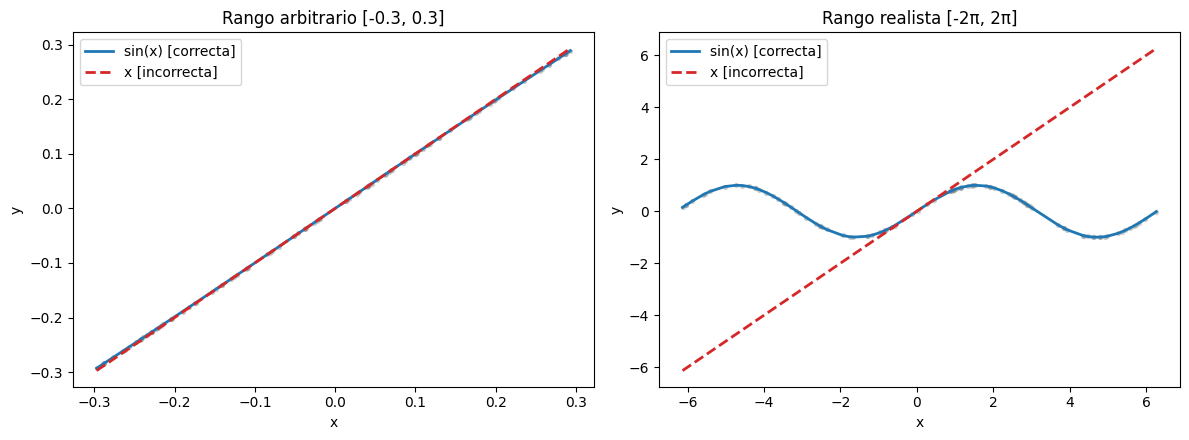

In [3]:
np.random.seed(0)

def target_f(x): return np.sin(x)
def wrong_f(x): return x

x_narrow = np.random.uniform(-0.3, 0.3, 100)
mse_wrong_narrow = np.mean((wrong_f(x_narrow) - target_f(x_narrow)) ** 2)
mse_correct_narrow = np.mean((target_f(x_narrow) - target_f(x_narrow)) ** 2)

x_wide = np.random.uniform(-2 * np.pi, 2 * np.pi, 100)
mse_wrong_wide = np.mean((wrong_f(x_wide) - target_f(x_wide)) ** 2)
mse_correct_wide = np.mean((target_f(x_wide) - target_f(x_wide)) ** 2)

print(f'{"rango de muestreo":28s}{"MSE de x (incorrecta)":>24s}{"MSE de sin(x) (correcta)":>26s}')
print(f'{"arbitrario [-0.3, 0.3]":28s}{mse_wrong_narrow:24.6f}{mse_correct_narrow:26.6f}')
print(f'{"realista [-2pi, 2pi]":28s}{mse_wrong_wide:24.6f}{mse_correct_wide:26.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (x_data, title) in zip(axes, [(x_narrow, 'Rango arbitrario [-0.3, 0.3]'), (x_wide, 'Rango realista [-2\u03c0, 2\u03c0]')]):
    order = np.argsort(x_data)
    xs = x_data[order]
    ax.plot(xs, target_f(xs), color='tab:blue', linewidth=2, label='sin(x) [correcta]')
    ax.plot(xs, wrong_f(xs), color='tab:red', linewidth=2, linestyle='--', label='x [incorrecta]')
    ax.scatter(x_data, target_f(x_data), s=8, alpha=0.3, color='gray')
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout()
plt.show()

## 3. La leccion: la metrica estructural (NED) no depende del rango elegido

In [4]:
print('Resumen:')
print(f'  Bajo el rango ARBITRARIO, el error numerico de "x" ({mse_wrong_narrow:.6f}) es casi identico al de "sin(x)" ({mse_correct_narrow:.6f}).')
print(f'  -> Un benchmark evaluado SOLO con MSE en ese rango declararia "x" como una solucion casi perfecta.')
print()
print(f'  Bajo el rango REALISTA, el error de "x" se dispara a {mse_wrong_wide:.4f}, mientras "sin(x)" sigue en {mse_correct_wide:.6f}.')
print(f'  -> El mismo par de hipotesis, evaluado con datos mas representativos, revela la diferencia real.')
print()
print(f'  La metrica NED entre "sin(x)" y "x" = {d_ned:.3f}, calculada UNA SOLA VEZ sobre la propia estructura')
print(f'  de las expresiones -- sin necesidad de elegir (ni de acertar) ningun rango de muestreo particular.')

Resumen:
  Bajo el rango ARBITRARIO, el error numerico de "x" (0.000003) es casi identico al de "sin(x)" (0.000000).
  -> Un benchmark evaluado SOLO con MSE en ese rango declararia "x" como una solucion casi perfecta.

  Bajo el rango REALISTA, el error de "x" se dispara a 14.2643, mientras "sin(x)" sigue en 0.000000.
  -> El mismo par de hipotesis, evaluado con datos mas representativos, revela la diferencia real.

  La metrica NED entre "sin(x)" y "x" = 1.000, calculada UNA SOLA VEZ sobre la propia estructura
  de las expresiones -- sin necesidad de elegir (ni de acertar) ningun rango de muestreo particular.


### Nota honesta sobre los resultados

- **NED simplificada, no la version completa del paper.** Implementamos una distancia de edicion de arboles **posicional** (compara el hijo $i$-esimo de cada nodo con el hijo $i$-esimo del otro, en el orden en que aparecen) en lugar del algoritmo de distancia de edicion de arboles optimo (tipo Zhang-Shasha, que prueba todas las correspondencias posibles entre subarboles para encontrar la transformacion de coste minimo). Nuestra version es mas simple pero captura el mismo principio: penaliza diferencias estructurales, no solo numericas.
- **Un unico par de hipotesis muy contrastante.** Elegimos deliberadamente $\sin(x)$ frente a $x$ porque es el ejemplo mas claro y pedagogico de "aproximacion local que colapsa fuera de rango" (la aproximacion de angulo pequeno de cualquier curso de fisica introductorio); el paper aplica esta comparacion sistematicamente sobre 120 ecuaciones del banco de datos Feynman con sus 120 contrapartes de rango realista (SRSD), mas otras 120 con variables irrelevantes anadidas deliberadamente.
- **No reproducimos el estudio con evaluadores humanos.** El paper valida que la metrica NED se correlaciona mejor con el juicio humano de "cuan correcta" es una formula descubierta que las metricas previas, mediante un estudio con participantes; aqui solo mostramos que NED **detecta** la diferencia estructural en nuestro ejemplo, sin validar la correlacion con juicio humano.
- **Rangos elegidos a mano, no calculados a partir de principios fisicos por variable.** El paper deriva los rangos "realistas" del dataset SRSD a partir de un analisis cuidadoso de los valores fisicamente plausibles de cada magnitud en cada una de las 120 ecuaciones (usando el contexto fisico especifico de cada formula); aqui simplemente elegimos $[-2\pi,2\pi]$ porque cubre naturalmente un periodo completo de la funcion seno.

Pese a estas simplificaciones, el cuaderno reproduce con claridad el argumento central del paper: el error numerico (MSE) por si solo es una metrica **fragil**, cuyo veredicto sobre si una formula es "correcta" puede depender enteramente del rango de muestreo elegido para evaluar -- mientras que una metrica estructural como NED juzga la formula descubierta por lo que **es**, no por donde se la evalua.